# Instacart — Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

DATA_PATH  = "../data/combined_instacart_data.csv"

import os
OUTPUT_DIR = os.path.join(os.path.abspath(''), "../outputs/")
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH, dtype={
    'user_id': 'int32', 'order_id': 'int32', 'product_id': 'int32',
    'aisle_id': 'int16', 'department_id': 'int8', 'order_number': 'int16',
    'order_dow': 'int8', 'order_hour_of_day': 'int8',
    'add_to_cart_order': 'int16', 'reordered': 'int8'
})
df['days_since_prior_order'] = df['days_since_prior_order'].astype('float32')
print("Shape:", df.shape)
print("Memory:", round(df.memory_usage(deep=True).sum()/1e6, 1), "MB")

Shape: (33819106, 15)
Memory: 3736.8 MB


## 2. User Features

In [3]:
user_total_orders = df.groupby('user_id')['order_id'].nunique().rename('user_total_orders')
user_reorder_rate = df.groupby('user_id')['reordered'].mean().rename('user_reorder_rate')
user_avg_days     = df.groupby('user_id')['days_since_prior_order'].mean().rename('user_avg_days_since_prior')
user_fav_hour     = df.groupby('user_id')['order_hour_of_day'].agg(lambda x: x.mode()[0]).rename('user_fav_hour')
user_fav_dow      = df.groupby('user_id')['order_dow'].agg(lambda x: x.mode()[0]).rename('user_fav_dow')

basket_size    = df.groupby('order_id')['product_id'].count().reset_index(name='basket_size')
user_avg_basket = (
    df[['user_id','order_id']].drop_duplicates()
    .merge(basket_size, on='order_id')
    .groupby('user_id')['basket_size'].mean()
    .rename('user_avg_basket_size')
)

user_features = pd.concat([
    user_total_orders, user_avg_basket, user_reorder_rate,
    user_avg_days, user_fav_hour, user_fav_dow
], axis=1).reset_index()

print("User features:", user_features.shape)
user_features.head()

User features: (206209, 7)


,user_id,user_total_orders,user_avg_basket_size,user_reorder_rate,user_avg_days_since_prior,user_fav_hour,user_fav_dow
0,1,11,6.363636,0.728571,19.200001,8,4
1,2,15,15.066667,0.464602,18.009390,11,1
2,3,12,7.333333,0.625000,11.487180,16,0
3,4,5,3.600000,0.055556,15.357142,15,4
4,5,5,9.200000,0.391304,12.314285,18,0


## 3. Product Features

In [4]:
product_total_orders = df.groupby('product_id')['order_id'].count().rename('product_total_orders')
product_unique_users = df.groupby('product_id')['user_id'].nunique().rename('product_unique_users')
product_reorder_rate = df.groupby('product_id')['reordered'].mean().rename('product_reorder_rate')
product_avg_position = df.groupby('product_id')['add_to_cart_order'].mean().rename('product_avg_position')
product_meta         = df.groupby('product_id')[['aisle_id','department_id']].first()

product_features = pd.concat([
    product_total_orders, product_unique_users,
    product_reorder_rate, product_avg_position, product_meta
], axis=1).reset_index()

print("Product features:", product_features.shape)
product_features.head()

Product features: (49685, 7)


,product_id,product_total_orders,product_unique_users,product_reorder_rate,product_avg_position,aisle_id,department_id
0,1,1928,743,0.614627,5.845954,61,19
1,2,94,81,0.138298,10.138298,104,13
2,3,283,74,0.738516,6.374558,94,7
3,4,351,190,0.458689,9.472934,38,1
4,5,16,6,0.625000,6.375000,5,13


## 4. User-Product Features

In [5]:
up_times_ordered = df.groupby(['user_id','product_id'])['order_id'].count().rename('up_times_ordered')
up_reorder_rate  = df.groupby(['user_id','product_id'])['reordered'].mean().rename('up_reorder_rate')
up_last_order    = df.groupby(['user_id','product_id'])['order_number'].max().rename('up_last_order_number')
up_first_order   = df.groupby(['user_id','product_id'])['order_number'].min().rename('up_first_order_number')

user_product_features = pd.concat([
    up_times_ordered, up_reorder_rate, up_last_order, up_first_order
], axis=1).reset_index()

print("User-Product features:", user_product_features.shape)
user_product_features.head()

User-Product features: (13863746, 6)


,user_id,product_id,up_times_ordered,up_reorder_rate,up_last_order_number,up_first_order_number
0,1,196,11,0.909091,11,1
1,1,10258,10,0.900000,11,2
2,1,10326,1,0.000000,5,5
3,1,12427,10,0.900000,10,1
4,1,13032,4,0.750000,11,2


## 5. Target Variable

In [6]:
target = df.groupby(['user_id','product_id'])['reordered'].max().rename('target').reset_index()
print("Target distribution:\n", target['target'].value_counts())
print("Reorder rate:", round(target['target'].mean(), 4))

Target distribution:
 target
0    8299266
1    5564480
Name: count, dtype: int64
Reorder rate: 0.4014


## 6. Merge All Features

In [7]:
train = user_product_features.merge(target, on=['user_id','product_id'])
train = train.merge(user_features, on='user_id')
train = train.merge(product_features, on='product_id')

train['up_order_recency']    = train['user_total_orders'] - train['up_last_order_number']
train['up_order_freq_ratio'] = train['up_times_ordered'] / train['user_total_orders']

print("Final training matrix:", train.shape)
print("Memory:", round(train.memory_usage(deep=True).sum()/1e6, 1), "MB")
train.head()

Final training matrix: (13863746, 21)
Memory: 1525.0 MB


,user_id,product_id,up_times_ordered,up_reorder_rate,up_last_order_number,up_first_order_number,target,user_total_orders,user_avg_basket_size,user_reorder_rate,...,user_fav_hour,user_fav_dow,product_total_orders,product_unique_users,product_reorder_rate,product_avg_position,aisle_id,department_id,up_order_recency,up_order_freq_ratio
0,1,196,11,0.909091,11,1,1,11,6.363636,0.728571,...,8,4,37298,8286,0.777843,3.732399,77,7,0,1.000000
1,1,10258,10,0.900000,11,2,1,11,6.363636,0.728571,...,8,4,2050,583,0.715610,4.268293,117,19,0,0.909091
2,1,10326,1,0.000000,5,5,0,11,6.363636,0.728571,...,8,4,5947,2061,0.653439,4.227846,24,4,6,0.090909
3,1,12427,10,0.900000,10,1,1,11,6.363636,0.728571,...,8,4,6697,1740,0.740182,4.781245,23,19,1,0.909091
4,1,13032,4,0.750000,11,2,1,11,6.363636,0.728571,...,8,4,3904,1323,0.661117,5.632172,121,14,0,0.363636


## 7. Feature Distributions

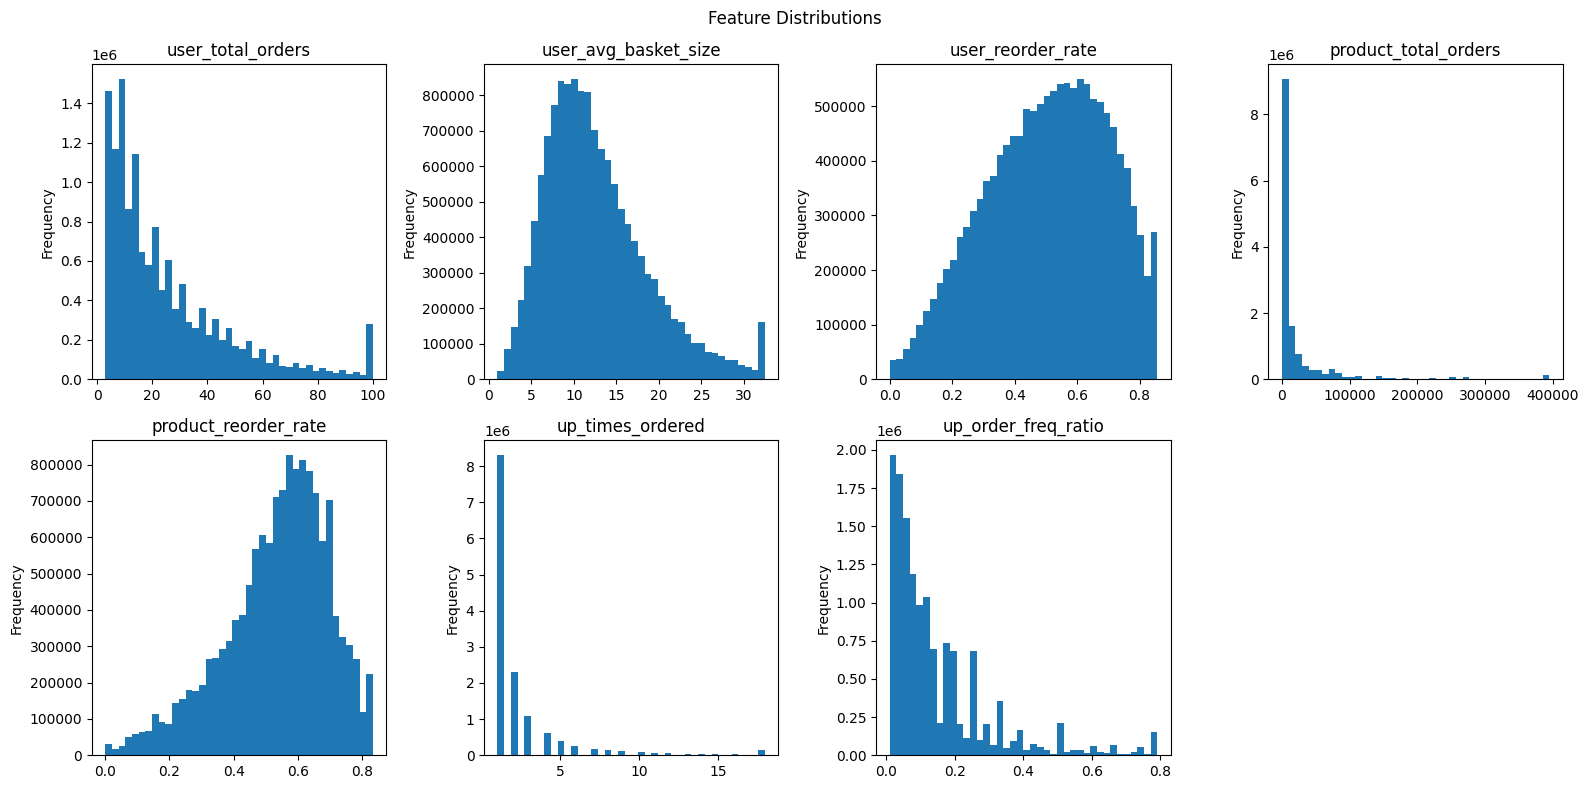

In [8]:
plot_cols = ['user_total_orders','user_avg_basket_size','user_reorder_rate',
             'product_total_orders','product_reorder_rate',
             'up_times_ordered','up_order_freq_ratio']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    train[col].clip(upper=train[col].quantile(0.99)).plot(kind='hist', bins=40, ax=axes[i])
    axes[i].set_title(col)
fig.delaxes(axes[-1])
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

## 8. Feature Correlation with Target

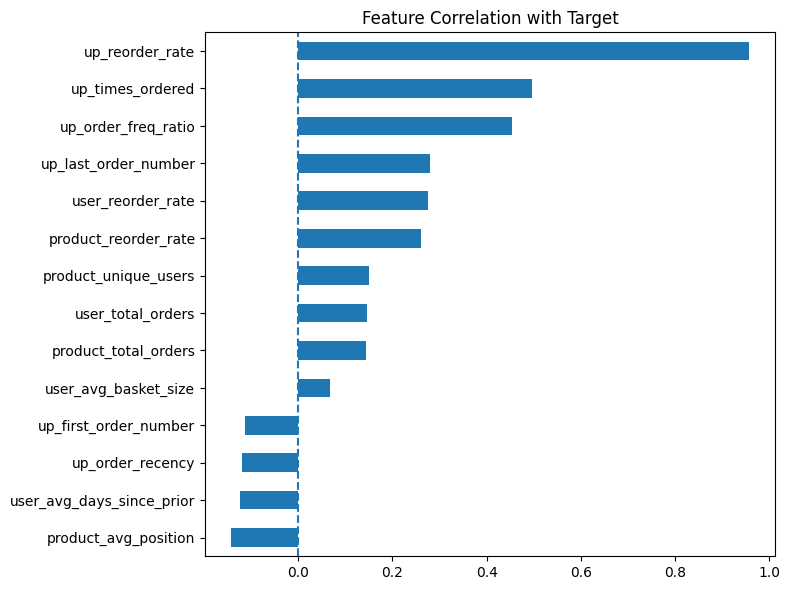

In [9]:
feat_cols = [
    'user_total_orders','user_avg_basket_size','user_reorder_rate',
    'user_avg_days_since_prior','product_total_orders','product_unique_users',
    'product_reorder_rate','product_avg_position',
    'up_times_ordered','up_reorder_rate','up_last_order_number',
    'up_first_order_number','up_order_recency','up_order_freq_ratio'
]
corr = train[feat_cols + ['target']].corr()['target'].drop('target').sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
corr.plot(kind='barh', ax=ax)
ax.axvline(0, linestyle='--')
ax.set_title('Feature Correlation with Target')
plt.tight_layout()
plt.show()

## 9. Class Balance

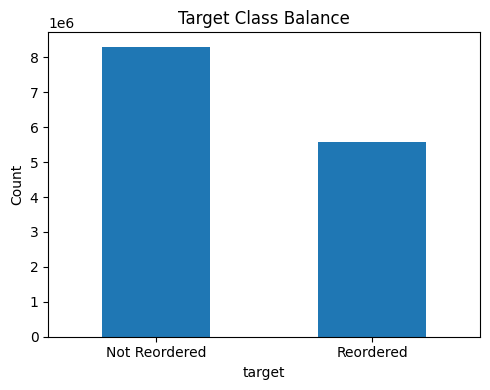

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
train['target'].value_counts().plot(kind='bar', ax=ax)
ax.set_xticklabels(['Not Reordered','Reordered'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Target Class Balance')
plt.tight_layout()
plt.show()

## 10. Save Outputs

In [11]:
train.to_parquet(OUTPUT_DIR + 'train_features.parquet', index=False)

product_names = df[['product_id','product_name','aisle','department']].drop_duplicates('product_id')
product_names.to_parquet(OUTPUT_DIR + 'product_names.parquet', index=False)

order_products = df[['order_id','user_id','product_name']].copy()
order_products.to_parquet(OUTPUT_DIR + 'order_products.parquet', index=False)

print("Saved train_features.parquet  :", train.shape)
print("Saved product_names.parquet   :", product_names.shape)
print("Saved order_products.parquet  :", order_products.shape)

Saved train_features.parquet  : (13863746, 21)
Saved product_names.parquet   : (49685, 4)
Saved order_products.parquet  : (33819106, 3)
